In [2]:
import sys
import numpy as np

In [3]:
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.wcs import WCS

In [4]:
import matplotlib
#matplotlib.use('Agg') # Must be before importing matplotlib.pyplot or pylab!
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import matplotlib.patheffects as path_effects
import matplotlib.patheffects as patheffects
import matplotlib.patches as mpatches
import matplotlib.colors as colors
from matplotlib.colors import LogNorm

In [5]:
import healpy as hp
import cmasher as cmr
from tqdm import tqdm

In [6]:
sys.path.append('/Users/soler/Documents/PYTHON/astroHOG/')
from astroHOGhp import *

In [7]:
nside=256

In [10]:
ipix=np.arange(hp.nside2npix(nside))
glon, glat = hp.pixelfunc.pix2ang(nside, ipix, nest=False, lonlat=True)
map1=np.zeros(hp.nside2npix(nside))
map1[(np.abs(glat) < 10.).nonzero()]=1.0

In [11]:
hdul=fits.open("../data/NHI_HPX.fits")
map1=hdul[1].data['NHI']

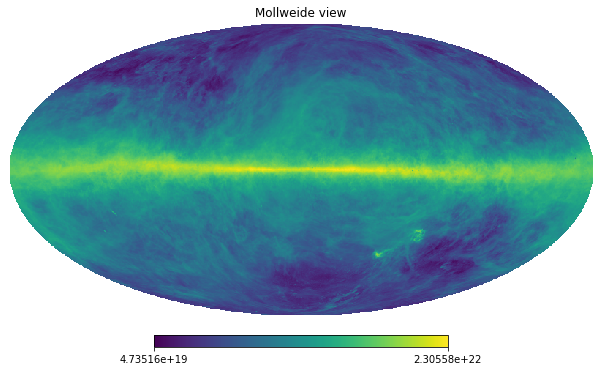

In [12]:
hp.mollview(map1, norm='log')

In [13]:
output=gradienthp(map1, niter=3, ksz=1.0)
dmap1dtheta=output['dtheta']
dmap1dphi=output['dphi']
smap1=output['smap']
gradmap1=output['gradmap']

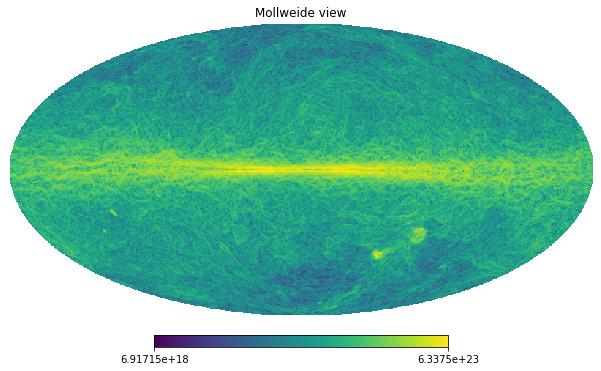

In [14]:
hp.mollview(gradmap1, norm='log')

In [15]:
hdul=fits.open("../data/COM_CompMap_Dust-GNILC-Model-Opacity_2048_R2.01.fits")
map2=hdul[1].data['TAU353']
s_map2=hdul[1].data['ERR_TAU']

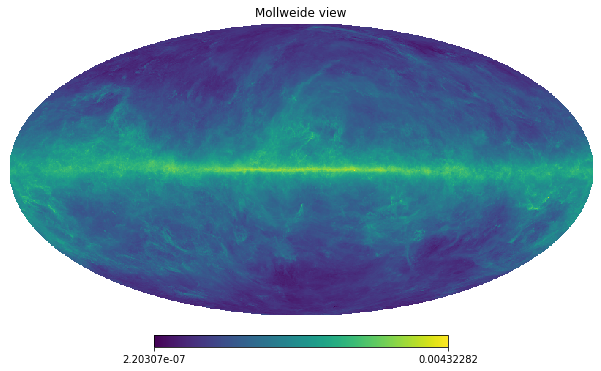

In [16]:
hp.mollview(map2, norm='log')

In [17]:
output=gradienthp(map2, niter=3, ksz=1.0)

In [18]:
dmap2dtheta=output['dtheta']
dmap2dphi=output['dphi']
smap2=output['smap']
gradmap2=output['gradmap']

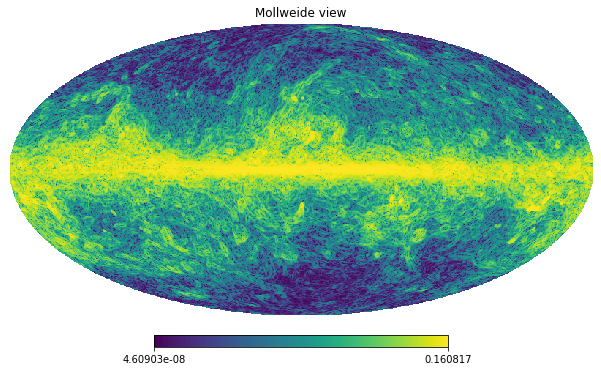

In [19]:
hp.mollview(gradmap2, norm='hist')

In [20]:
print(np.shape(map1),np.shape(map2))

(12582912,) (50331648,)


In [21]:
rmap2=hp.pixelfunc.ud_grade(map2, hp.npix2nside(np.size(map1)))

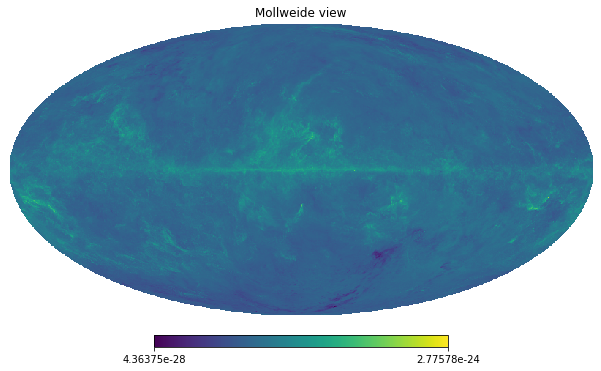

In [22]:
hp.mollview(rmap2/map1, norm='log')

Text(0, 0.5, '$\\tau_{353}$')

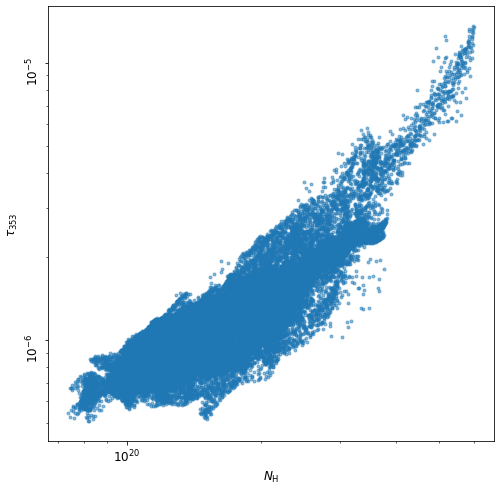

In [23]:
good=(glat < -60.).nonzero()
fig=plt.figure(figsize=(8.0,8.0))
plt.rc('font', size=12)
ax0=fig.add_subplot(111)
ax0.set_xscale('log') 
ax0.set_yscale('log') 
ax0.scatter(map1[good],rmap2[good], marker='.', alpha=0.5)
ax0.tick_params(axis="y", rotation=90)
ax0.set_xlabel(r'$N_{\rm H}$')
ax0.set_ylabel(r'$\tau_{353}$')

In [24]:
testhog=astroHOGhp(map1, map2, ksz=1.0, nsideout=16, computeVmap=True)

100%|██████████| 3072/3072 [00:15<00:00, 195.47it/s]


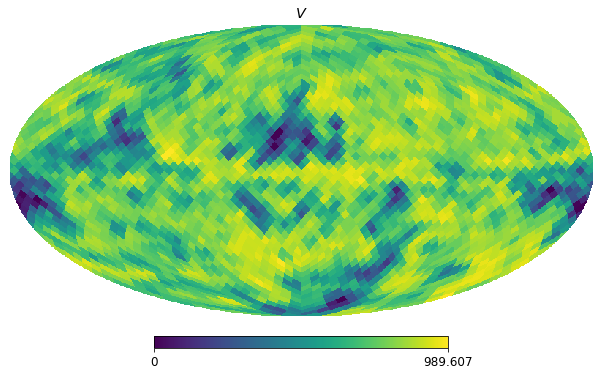

In [26]:
hp.mollview(testhog['Vd'], min=0., title=r'$V$')
#hp.mollview(testhog['alphad'], min=0., cmap='hsv')
plt.savefig("HOG_HIandTau353GHz.png")

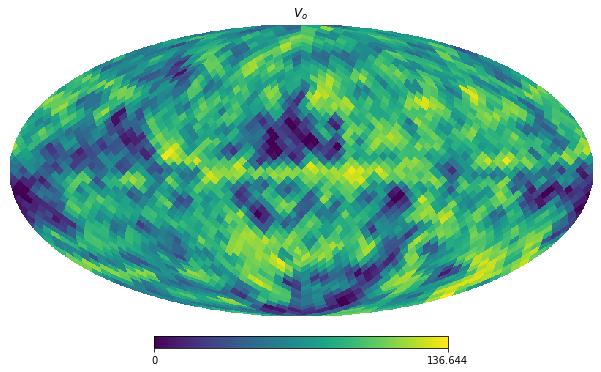

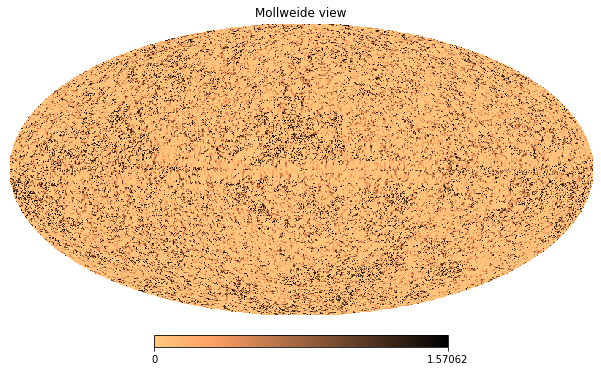

In [170]:
hp.mollview(testhog['Vo'], min=0., title=r'$V_{o}$')
hp.mollview(testhog['alphao'], min=0., cmap='copper_r')

In [121]:
print("Vd=",testhog['Vdall'])
print("Vo=",testhog['Voall'])

Vd= 1303400.6653230833
Vo= 819736.0433651841


Text(0, 0.5, '$V_{\\rm d}$')

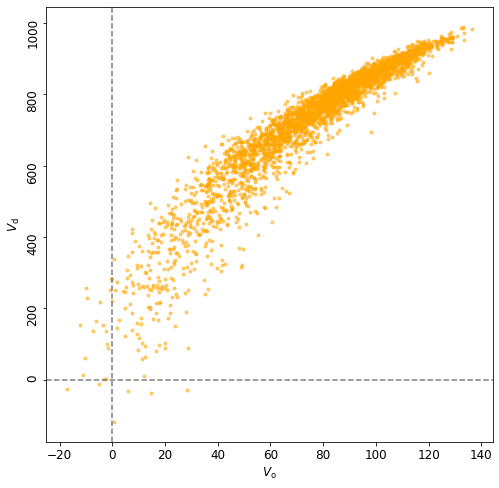

In [201]:
fig=plt.figure(figsize=(8.0,8.0))
plt.rc('font', size=12)
ax0=fig.add_subplot(111)
ax0.scatter(testhog['Vo'],testhog['Vd'], alpha=0.5, marker='.', color='orange')
ax0.axvline(x=0., color='grey', linestyle='dashed')
ax0.axhline(y=0., color='grey', linestyle='dashed')
ax0.tick_params(axis="y", rotation=90)
ax0.set_xlabel(r'$V_{\rm o}$')
ax0.set_ylabel(r'$V_{\rm d}$')

In [148]:
reso=1.5
nsideout=hp.npix2nside(np.size(testhog['Vd']))
pxsz=int(hp.pixelfunc.nside2resol(nsideout, arcmin=True)/reso)

In [149]:
iVdmax=np.min((testhog['Vd']==np.nanmax(testhog['Vd'])).nonzero())
lVdmax, bVdmax = hp.pixelfunc.pix2ang(hp.npix2nside(np.size(testhog['Vd'])), iVdmax, lonlat=True)

87.4384459321948 92.5615540678052 -2.561554067805204 2.561554067805204
87.4384459321948 92.5615540678052 -2.561554067805204 2.561554067805204
87.4384459321948 92.5615540678052 -2.561554067805204 2.561554067805204


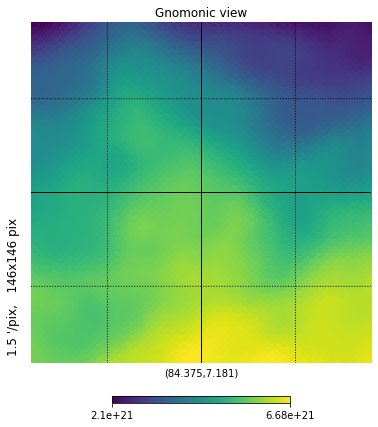

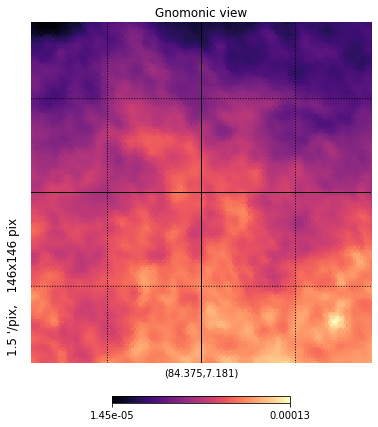

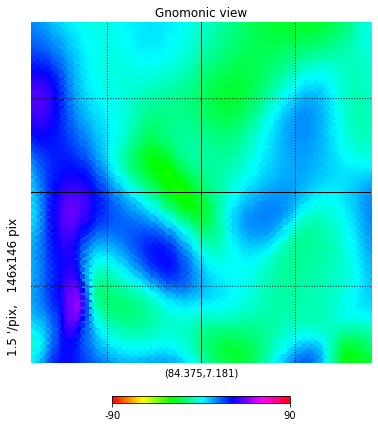

In [155]:
hp.gnomview(map1, rot=[lVdmax, bVdmax], xsize=pxsz, norm='log', cmap='viridis')
hp.graticule()
hp.gnomview(map2, rot=[lVdmax, bVdmax], xsize=pxsz, norm='log', cmap='magma')
hp.graticule()
hp.gnomview(np.rad2deg(testhog['alphad']), rot=[lVdmax, bVdmax], xsize=pxsz, cmap='hsv', min=-90., max=90.)
hp.graticule()

In [150]:
iVomax=np.min((testhog['Vo']==np.nanmax(testhog['Vo'])).nonzero())
lVomax, bVomax = hp.pixelfunc.pix2ang(hp.npix2nside(np.size(testhog['Vo'])), iVomax, lonlat=True)

87.4384459321948 92.5615540678052 -2.561554067805204 2.561554067805204
87.4384459321948 92.5615540678052 -2.561554067805204 2.561554067805204
87.4384459321948 92.5615540678052 -2.561554067805204 2.561554067805204


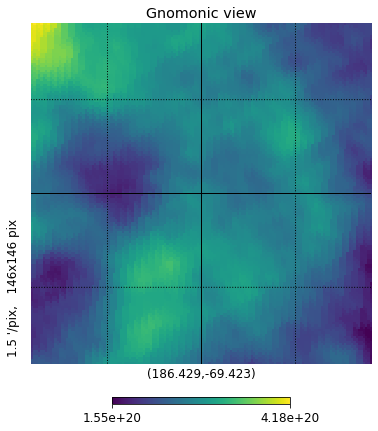

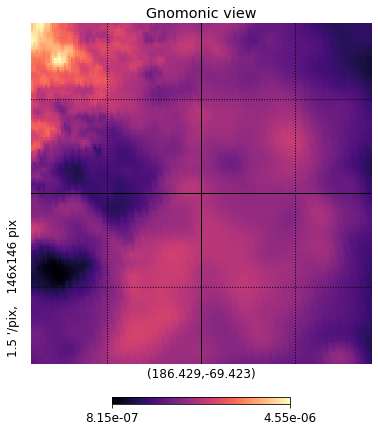

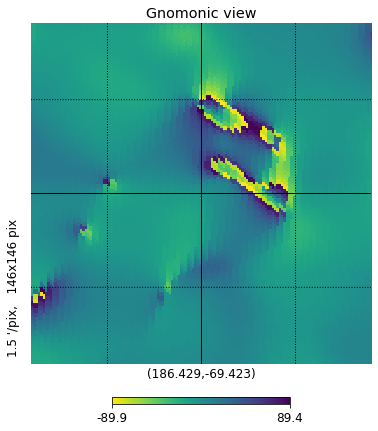

In [203]:
hp.gnomview(map1, rot=[lVomax, bVomax], xsize=pxsz, norm='log', cmap='viridis')
hp.graticule()
hp.gnomview(map2, rot=[lVomax, bVomax], xsize=pxsz, norm='log', cmap='magma')
hp.graticule()
hp.gnomview(np.rad2deg(testhog['alphao']), rot=[lVomax, bVomax], xsize=pxsz, cmap='viridis_r')
hp.graticule()